# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [1]:

import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:

# Check for missing values and data types
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:

# Summary statistics

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Age
Average age: 40 years
Youngest customer: 17
Oldest customer: 98
Most customers fall between 32 and 47 years (25th–75th percentile)

The bank's customer base is primarily composed of middle-aged individuals, with the majority between 32 and 47 years old.


Call Duration
Average call duration: 258 seconds
Maximum: 4918 seconds (~82 minutes)

There are some extremely long calls, indicating possible outliers. Call duration may have a strong relationship with subscription success.

Campaign Contacts
Average contacts per customer: 2.57
Maximum contacts: 56

Most customers were contacted only a few times, but a small number received many follow-up calls.

Previous Contacts
Median = 0
75% percentile = 0

Most customers had never been contacted before this campaign.

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable


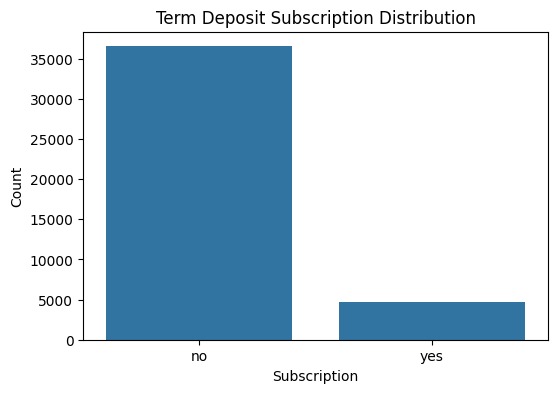

y
no     36548
yes     4640
Name: count, dtype: int64

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.show()

df['y'].value_counts()

### Insight

The majority of customers (36,548) did not subscribe to a term deposit, while only 4,640 customers subscribed.

This indicates that the dataset is highly imbalanced, with approximately 89% of customers declining the offer and only 11% accepting it.

The low conversion rate suggests that identifying the characteristics of customers who are likely to subscribe could significantly improve future marketing campaigns.

## Age Distribution Analysis

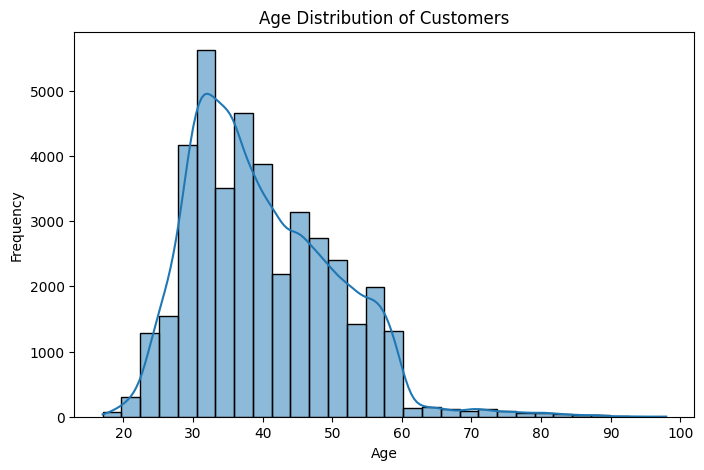

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### Insight

The age distribution indicates that the majority of customers fall between 30 and 45 years old, with the highest concentration around the early 30s.

The distribution is positively skewed, suggesting that younger and middle-aged individuals form the primary customer base, while older customers represent a smaller segment.

This indicates that the bank's marketing campaigns are primarily reaching economically active individuals.

## Job Distribution Analysis

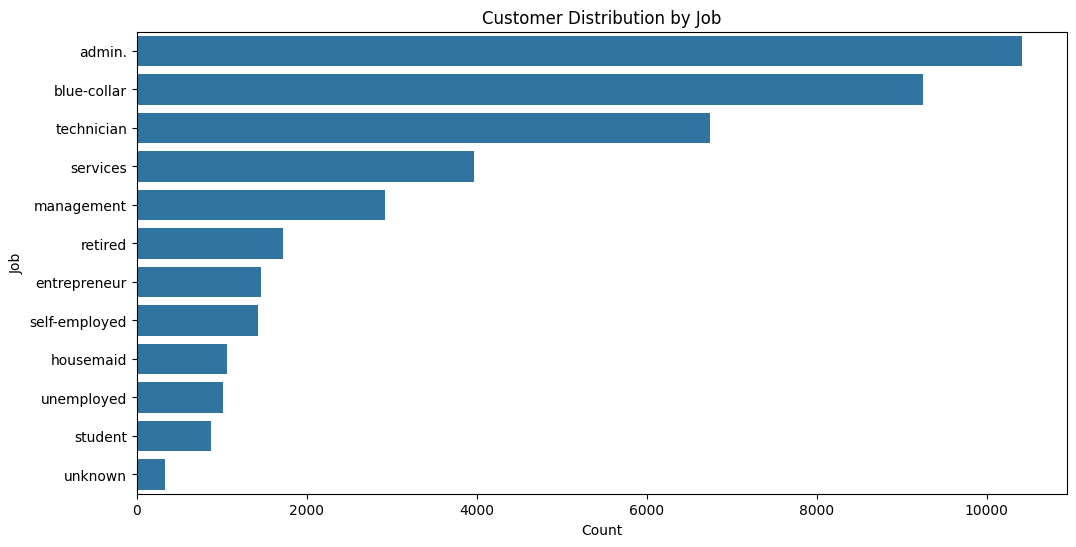

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    data=df,
    order=df['job'].value_counts().index
)

plt.title('Customer Distribution by Job')
plt.xlabel('Count')
plt.ylabel('Job')

plt.show()

### Insight

The customer base is dominated by administrative, blue-collar, and technician occupations. Together, these groups account for a significant portion of the bank's customers.

Administrative employees represent the largest customer segment, followed by blue-collar workers and technicians. This suggests that the bank's marketing campaigns primarily target working professionals and skilled labor groups.

Smaller segments such as students, unemployed individuals, and housemaids represent a relatively small proportion of the customer base.

## Education Distribution Analysis

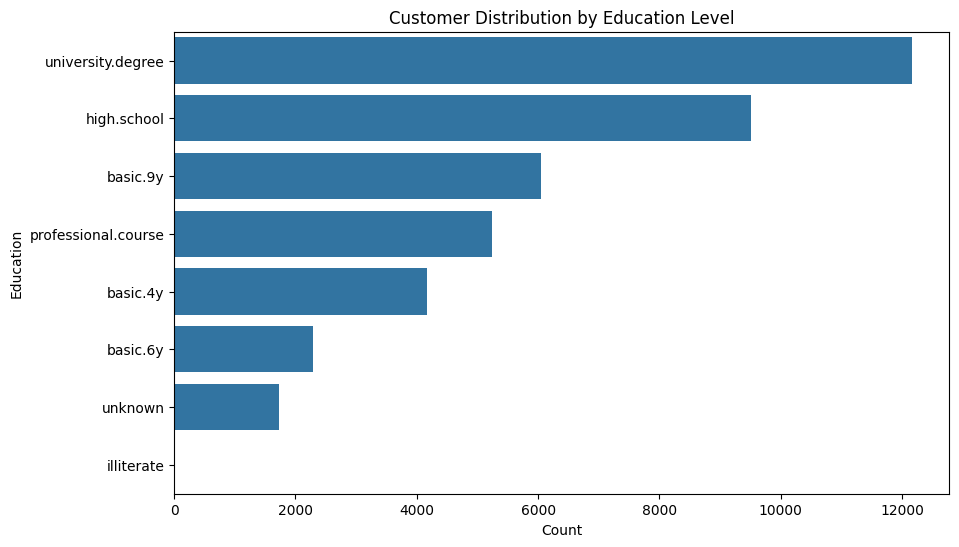

In [9]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='education',
    data=df,
    order=df['education'].value_counts().index
)

plt.title('Customer Distribution by Education Level')
plt.xlabel('Count')
plt.ylabel('Education')

plt.show()

### Insight

The majority of customers have a university degree, followed by high school education. This suggests that the bank's customer base is relatively well educated.

Customers with higher educational qualifications represent a substantial portion of the dataset, indicating that educational background may play an important role in customer engagement and financial decision-making.

The number of illiterate customers is extremely low, showing that the bank primarily serves customers with formal education.

## Housing Loan vs Subscription

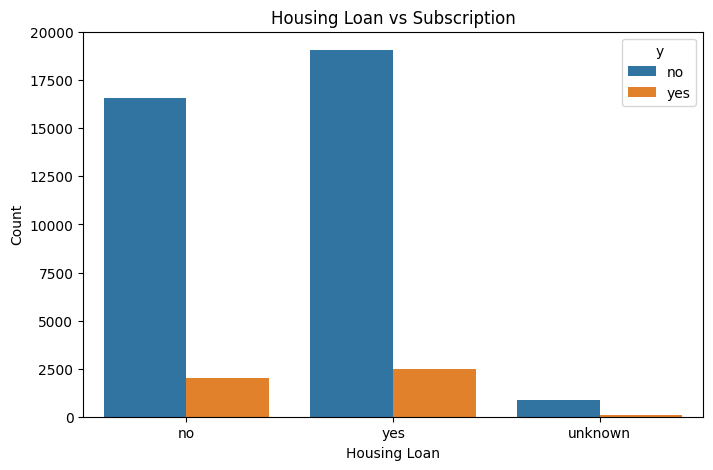

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(x='housing', hue='y', data=df)

plt.title('Housing Loan vs Subscription')
plt.xlabel('Housing Loan')
plt.ylabel('Count')

plt.show()

### Insight

Most customers did not subscribe to the term deposit regardless of their housing loan status.

Customers with housing loans form a slightly larger portion of the dataset, but the proportion of subscriptions appears similar between customers with and without housing loans.

This suggests that housing loan status may have a limited influence on term deposit subscription decisions.

## Correlation Analysis

The correlation matrix was used to examine relationships between numerical variables in the dataset. Understanding these relationships helps identify important patterns and potential multicollinearity before model building.

## Correlation Heatmap

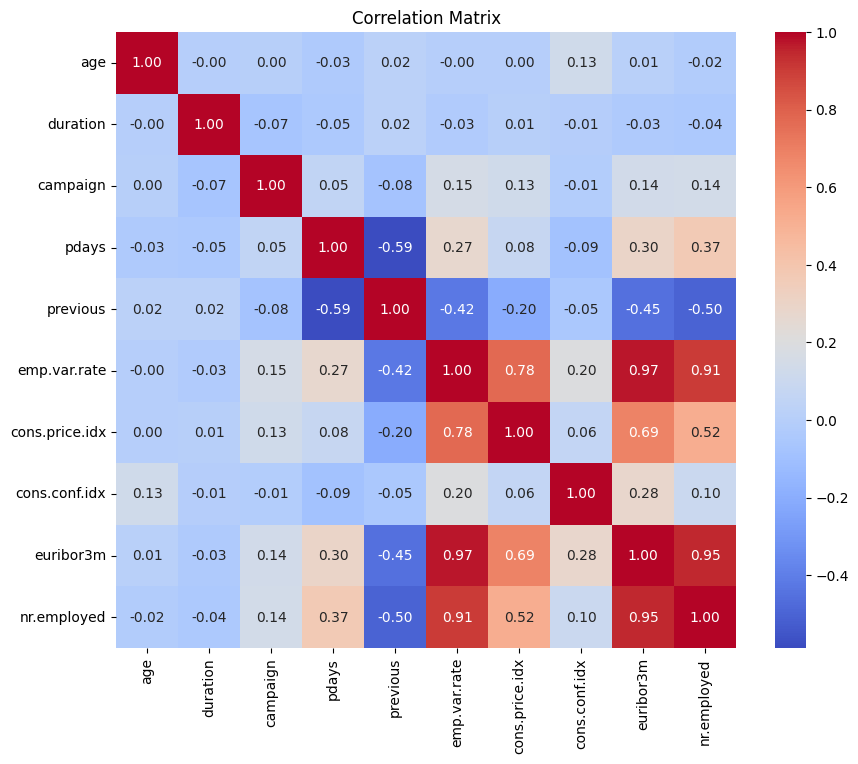

In [13]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

### Correlation Analysis

The correlation heatmap reveals strong positive relationships among economic indicators such as euribor3m, emp.var.rate, and nr.employed.

The strongest correlation was observed between euribor3m and emp.var.rate (0.97), suggesting that these variables tend to move together.

Most customer-related variables showed weak correlations, indicating that they provide distinct information and may contribute independently to predictive modeling.

### Key Insights

- euribor3m and emp.var.rate have a strong positive correlation (0.97).
- euribor3m and nr.employed have a strong positive correlation (0.95).
- pdays and previous have a moderate negative correlation (-0.59).
- Most customer-related variables show weak correlations, indicating independent contributions to analysis.


## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- The dataset includes customer demographics and contact details, which can be useful for segmentation.
- A majority of customers do not subscribe to term deposits, indicating an imbalanced dataset.
- Further preprocessing, feature engineering, and modeling would be the next steps for predictive analysis.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
